Author: **Fahim Rajit Hossain**,

Bangladesh Team Leader, Astronomy Prompt Engineer, Mercor/Former Research Fellow,Chalmers

# Estimating Stellar Properties from Limited Spectral Data (25 Points)

Space telescopes often observe only a limited wavelength range. Nevertheless, fundamental stellar properties such as effective temperature, color, luminosity, and spectral class can still be inferred from incomplete spectral information.

In this problem, astronomers use a fictional ultraviolet space telescope, **SST**, which observes only over the wavelength range **200–300 nm**. The telescope observes a star named **MM 1962**. The star has the same radius as Vega, but all other physical properties may differ. Assume throughout that both Vega and MM 1962 behave as ideal blackbodies.

The absolute bolometric magnitude of Vega is **0.582**. A calibrated spectrum of Vega, showing the spectral flux density **bλ = db/dλ**, is provided separately in the answer sheet.

---

## (a) Derivation of Band-Integrated Flux (3 points)

Consider a star of radius **R**, distance **d**, and effective temperature **T**.

Show that the flux received through a photometric band with central wavelength **λ** and bandwidth **Δλ** is

$$
b(\lambda,\Delta\lambda)
=
\pi\left(\frac{R}{d}\right)^2
\int_{\lambda-\Delta\lambda/2}^{\lambda+\Delta\lambda/2}
B_\lambda(\lambda,T)\,d\lambda,
$$

where

$$
B_\lambda(\lambda,T)
=
\frac{2hc^2}{\lambda^5}
\frac{1}
{\exp\!\left(\dfrac{hc}{\lambda kT}\right)-1}
$$

is Planck's spectral radiance.

---

## (b) Vega Photometry and Temperature (5 points)

The Johnson photometric bands are listed below.

| Band | Symbol | Central wavelength (μm) | Relative bandwidth Δλ/λ |
|:---|:---:|:---:|:---:|
| Blue | B | 0.44 | 0.22 |
| Visual | V | 0.55 | 0.16 |

Define the band-integrated fluxes **b_B** and **b_V**.

Using the Vega spectrum provided in the answer sheet,

1. Estimate the integrated fluxes **b_B** and **b_V**. **(2 points)**

2. Estimate Vega's effective temperature by comparing the observed spectrum with Planck curves of different temperatures. Compare your result with the accepted value. **(3 points)**

---

## (c) Effective Temperature of MM 1962 (4 points)

The SST obtained the following ultraviolet measurements of the observed spectral flux density.

| No. | bλ (10¹³ W m⁻³) | Wavelength (nm) |
|:--:|:--:|:--:|
| 1 | 3.56 | 200 |
| 2 | 4.23 | 212 |
| 3 | 5.92 | 229 |
| 4 | 7.43 | 252 |
| 5 | 8.12 | 260 |
| 6 | 9.33 | 281 |
| 7 | 10.28 | 300 |

The answer sheet contains four candidate blackbody spectra corresponding to effective temperatures of

- 7000 K
- 7200 K
- 7700 K
- 8000 K

Each spectrum has already been multiplied by a constant so that its value at **300 nm** matches the observed value in the table. Consequently, the unknown factor

$$
\pi\left(\frac{R}{d}\right)^2
$$

has been removed.

Explain why, after this normalization, only the **shape** of the spectrum depends on the stellar temperature.

Using the supplied spectra,

- determine the best-fit effective temperature;
- determine reasonable upper and lower limits by identifying the highest- and lowest-temperature models that still provide acceptable agreement with the observations;
- briefly justify your choices.

---

## (d) Synthetic Johnson Photometry (6 points)

Using the best-fit, upper-limit, and lower-limit blackbody models selected in part (c), estimate the average spectral flux densities

$$
\bar b_B
=
\frac{1}{\Delta\lambda_B}
\int_{\lambda_B-\Delta\lambda_B/2}^{\lambda_B+\Delta\lambda_B/2}
b_\lambda\,d\lambda,
$$

and

$$
\bar b_V
=
\frac{1}{\Delta\lambda_V}
\int_{\lambda_V-\Delta\lambda_V/2}^{\lambda_V+\Delta\lambda_V/2}
b_\lambda\,d\lambda.
$$

For each of the three models, construct a single plot showing

- the SST measurements from the table above;
- the three normalized blackbody spectra corresponding to the best-fit, upper-limit, and lower-limit temperatures;
- the corresponding average spectral flux densities in the Johnson **B** and **V** photometric bands.

Represent each photometric measurement by its central wavelength together with a horizontal bar extending from

$$
\lambda-\frac{\Delta\lambda}{2}
$$

to

$$
\lambda+\frac{\Delta\lambda}{2}.
$$

Wavelength uncertainties may be neglected.

---

## (e) Color Index (3 points)

Using the synthetic Johnson **B**- and **V**-band photometry obtained in part (d), determine the **(B − V)** color index of MM 1962 for the

- best-fit,
- upper-limit,
- lower-limit

blackbody models.

Report the color index in the form

$$
(B-V_{\rm best})^{+u}_{-l},
$$

where **u** is the difference between the upper-limit value and the best-fit value, and **l** is the difference between the best-fit value and the lower-limit value.

---

## (f) Luminosity, H–R Diagram, and Spectral Classification (4 points)

Using the best-fit, upper-limit, and lower-limit temperatures obtained in part (c), together with the fact that MM 1962 has the same radius as Vega,

1. determine the corresponding absolute bolometric magnitudes;
2. place MM 1962 on a Hertzsprung–Russell diagram;
3. determine its spectral class.

Report the spectral classification in the format

**Upper limit:** G0

**Best fit:** K1

**Lower limit:** K5

Assume that each spectral class is uniformly divided into ten subclasses (for example, A0–A9), so that consecutive subclasses correspond to equal intervals in effective temperature.

Best-fit temperature = 7720.1 K
Scale factor         = 1.0433e+00
Approximate range:
7692 K  <  T  <  7745 K


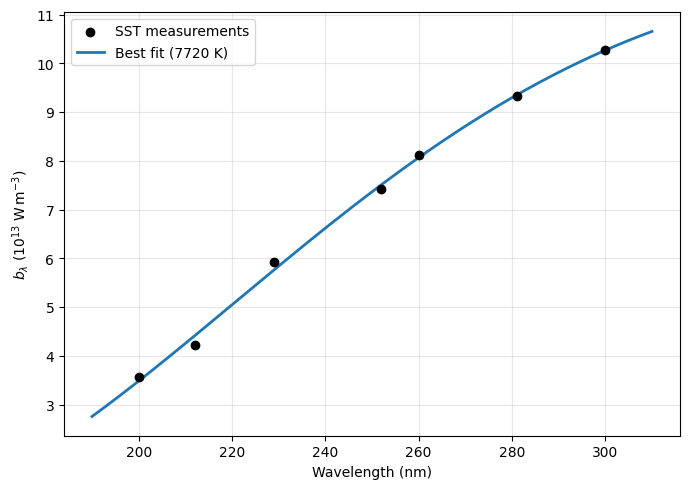

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# -------------------------------------------------
# Physical constants (SI)
# -------------------------------------------------
h = 6.62607015e-34
c = 2.99792458e8
k = 1.380649e-23

# -------------------------------------------------
# SST observations
# -------------------------------------------------
lam_nm = np.array([200,212,229,252,260,281,300])
lam = lam_nm*1e-9

# observed spectral flux density
b = np.array([
    3.56,
    4.23,
    5.92,
    7.43,
    8.12,
    9.33,
    10.28
])*1e13

# -------------------------------------------------
# Planck function
# -------------------------------------------------
def planck(lam,T):

    x = h*c/(lam*k*T)

    return (2*h*c**2)/(lam**5)/(np.exp(x)-1)

# -------------------------------------------------
# Compute best normalization for a given T
# -------------------------------------------------
def scale_factor(model,data):

    return np.dot(data,model)/np.dot(model,model)

# -------------------------------------------------
# Chi-square (actually SSE)
# -------------------------------------------------
def objective(T):

    model = planck(lam,T)

    A = scale_factor(model,b)

    residual = b - A*model

    return np.sum(residual**2)

# -------------------------------------------------
# Fit temperature
# -------------------------------------------------
result = minimize_scalar(
    objective,
    bounds=(4000,20000),
    method='bounded'
)

T_best = result.x

# Best normalization
model = planck(lam,T_best)
A_best = scale_factor(model,b)

print(f"Best-fit temperature = {T_best:.1f} K")
print(f"Scale factor         = {A_best:.4e}")

# -------------------------------------------------
# Estimate uncertainty
#
# Temperature where
# SSE = SSEmin + 5%
# -------------------------------------------------
SSE_min = objective(T_best)

temps = np.linspace(4000,20000,3000)

SSE = np.array([objective(T) for T in temps])

limit = 1.05*SSE_min

good = temps[SSE <= limit]

T_low = good.min()
T_high = good.max()

print(f"Approximate range:")
print(f"{T_low:.0f} K  <  T  <  {T_high:.0f} K")

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(7,5))

plt.scatter(
    lam_nm,
    b/1e13,
    color='black',
    zorder=3,
    label='SST measurements'
)

lam_plot = np.linspace(190,310,500)
model_plot = planck(lam_plot*1e-9,T_best)

plt.plot(
    lam_plot,
    A_best*model_plot/1e13,
    lw=2,
    label=f'Best fit ({T_best:.0f} K)'
)

plt.xlabel("Wavelength (nm)")
plt.ylabel(r"$b_\lambda$ ($10^{13}\ {\rm W\,m^{-3}}$)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

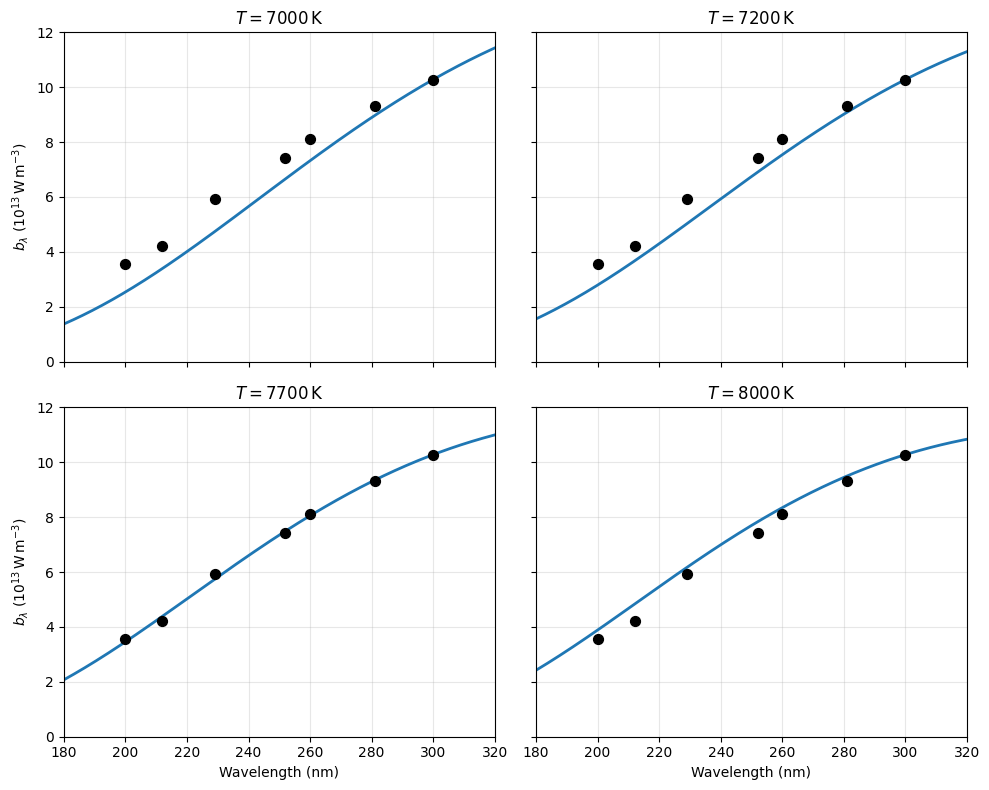

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Physical constants (SI)
# ----------------------------------------------------
h = 6.62607015e-34      # Planck constant
c = 2.99792458e8        # Speed of light
k = 1.380649e-23        # Boltzmann constant

# ----------------------------------------------------
# SST observations
# ----------------------------------------------------
lam_nm = np.array([200, 212, 229, 252, 260, 281, 300])
lam = lam_nm * 1e-9

b_obs = np.array([
    3.56,
    4.23,
    5.92,
    7.43,
    8.12,
    9.33,
    10.28
])

# ----------------------------------------------------
# Planck spectral radiance
# ----------------------------------------------------
def planck_lambda(lam, T):
    exponent = h * c / (lam * k * T)
    return (2 * h * c**2) / (lam**5 * (np.exp(exponent) - 1))

# ----------------------------------------------------
# Candidate temperatures
# ----------------------------------------------------
temps = [7000, 7200, 7700, 8000]

# ----------------------------------------------------
# Smooth wavelength grid
# ----------------------------------------------------
lam_plot_nm = np.linspace(180, 320, 600)
lam_plot = lam_plot_nm * 1e-9

# ----------------------------------------------------
# Figure
# ----------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    sharex=True,
    sharey=True
)

for ax, T in zip(axes.ravel(), temps):

    # Theoretical spectrum at observed wavelengths
    model = planck_lambda(lam, T)

    # ------------------------------------------------
    # Normalize so that the theoretical spectrum
    # matches the observed value at 300 nm
    # ------------------------------------------------
    b300_obs = b_obs[-1]
    b300_model = model[-1]

    scale = b300_obs / b300_model

    # Smooth normalized spectrum
    model_plot = scale * planck_lambda(lam_plot, T)

    # Plot normalized theoretical spectrum
    ax.plot(
        lam_plot_nm,
        model_plot,
        lw=2
    )

    # Plot observed measurements
    ax.scatter(
        lam_nm,
        b_obs,
        s=50,
        color='black',
        zorder=3
    )

    ax.set_title(f"$T={T}\\,\\mathrm{{K}}$", fontsize=12)

    ax.set_xlim(180, 320)
    ax.set_ylim(0, 12)

    ax.grid(True, alpha=0.3)

# Axis labels
for ax in axes[:, 0]:
    ax.set_ylabel(r"$b_\lambda\ (10^{13}\,\mathrm{W\,m^{-3}})$")

for ax in axes[1]:
    ax.set_xlabel("Wavelength (nm)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1582/2280607302.py:115: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  b_bar = np.trapz(values,grid)/(l2-l1)


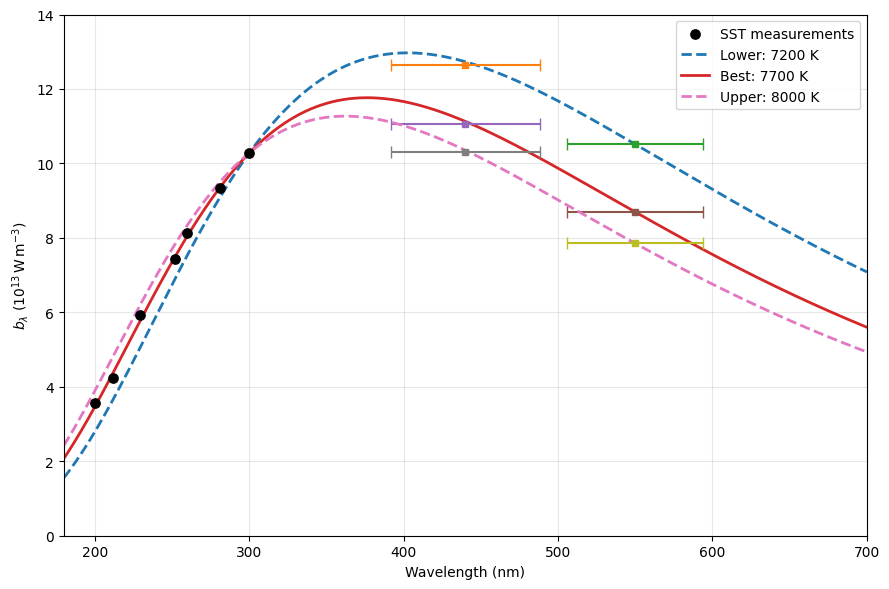

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Physical constants (SI)
# =====================================================
h = 6.62607015e-34
c = 2.99792458e8
k = 1.380649e-23

# =====================================================
# Planck function
# =====================================================
def planck_lambda(lam, T):
    x = h*c/(lam*k*T)
    return (2*h*c**2)/(lam**5)/(np.exp(x)-1)

# =====================================================
# SST observations
# =====================================================
lam_obs_nm = np.array([200,212,229,252,260,281,300])
lam_obs = lam_obs_nm*1e-9

b_obs = np.array([
    3.56,
    4.23,
    5.92,
    7.43,
    8.12,
    9.33,
    10.28
])

# =====================================================
# Temperatures selected in Part (c)
# =====================================================
T_low  = 7200
T_best = 7700
T_high = 8000

temperatures = [
    ("Lower",T_low,"--"),
    ("Best",T_best,"-"),
    ("Upper",T_high,"--")
]

# =====================================================
# Wavelength grid
# =====================================================
lam_plot_nm = np.linspace(180,700,1200)
lam_plot = lam_plot_nm*1e-9

# =====================================================
# Johnson filters
# =====================================================
filters = {
    "B": (440.0,0.22),
    "V": (550.0,0.16)
}

# =====================================================
# Figure
# =====================================================
plt.figure(figsize=(9,6))

# -----------------------------------------------------
# Plot SST measurements
# -----------------------------------------------------
plt.scatter(
    lam_obs_nm,
    b_obs,
    color="black",
    s=45,
    zorder=5,
    label="SST measurements"
)

# =====================================================
# Plot each normalized spectrum
# =====================================================
for label,T,style in temperatures:

    # Planck spectrum at 300 nm
    model300 = planck_lambda(np.array([300e-9]),T)[0]

    # Normalization
    scale = b_obs[-1]/model300

    # Smooth spectrum
    spectrum = scale*planck_lambda(lam_plot,T)

    plt.plot(
        lam_plot_nm,
        spectrum,
        linestyle=style,
        linewidth=2,
        label=f"{label}: {T} K"
    )

    # -------------------------------------------------
    # Average spectral flux density in each filter
    # -------------------------------------------------
    for band,(lam0,frac) in filters.items():

        width = lam0*frac

        l1 = (lam0-width/2)*1e-9
        l2 = (lam0+width/2)*1e-9

        grid = np.linspace(l1,l2,500)

        values = scale*planck_lambda(grid,T)

        # average spectral flux density
        b_bar = np.trapz(values,grid)/(l2-l1)

        plt.errorbar(
            lam0,
            b_bar,
            xerr=width/2,
            fmt='s',
            capsize=4,
            ms=5
        )

# =====================================================
# Cosmetics
# =====================================================
plt.xlim(180,700)
plt.ylim(0,14)

plt.xlabel("Wavelength (nm)")
plt.ylabel(r"$b_\lambda\ (10^{13}\,\mathrm{W\,m^{-3}})$")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()